<a href="https://colab.research.google.com/github/grsart/BiomolComp/blob/main/P02/Pratica_02A_MatrizesSubstituicao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inspeção de Matrizes de Substituição com o BioPython

Nesta parte da prática, vamos inspecionar algumas matrizes de substituição que já estão presentes no Biopython como parte da Biblioteca.

As matrizes de substituição são muito importantes para a obtenção de um ali-
nhamento. Há várias matrizes de substituição disponíveis. Dentre estas, as
mais usadas são as matrizes BLOSUM62 e as matrizes PAM, como a PAM250, por
exemplo. O Biopython tem as matrizes embutidas. Estas matrizes podem ser
facilmente visualizadas a partir da biblioteca.

## Instalando o BioPython

In [1]:
!pip3 install biopython==1.85
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from Bio.Align import substitution_matrices, PairwiseAligner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 25.1 MB/s eta 0:00:00


### Listando as matrizes de substituição existentes no BioPython

In [2]:
substitution_matrices.load()

['BENNER22',
 'BENNER6',
 'BENNER74',
 'BLASTN',
 'BLASTP',
 'BLOSUM45',
 'BLOSUM50',
 'BLOSUM62',
 'BLOSUM80',
 'BLOSUM90',
 'DAYHOFF',
 'FENG',
 'GENETIC',
 'GONNET1992',
 'HOXD70',
 'JOHNSON',
 'JONES',
 'LEVIN',
 'MCLACHLAN',
 'MDM78',
 'MEGABLAST',
 'NUC.4.4',
 'PAM250',
 'PAM30',
 'PAM70',
 'RAO',
 'RISLER',
 'SCHNEIDER',
 'STR',
 'TRANS']

Vamos analisar algumas destas matrizes de substituição. Começando pela PAM250 (*Point Accepted Mutatio*n) e, em seguida, passando para a BLOSUM62 (*Blocks Substitution Matrix*).

**Q1-** Compare as duas matrizes. Existem diferenças entre elas? Quais as mais marcantes?

In [3]:
matrix_pam250 = substitution_matrices.load("PAM250")
print(matrix_pam250)

#  
#  This matrix was produced by "pam" Version 1.0.6 [28-Jul-93]
#  
#  PAM 250 substitution matrix, scale = ln(2)/3 = 0.231049
#  
#  Expected score = -0.844, Entropy = 0.354 bits
#  
#  Lowest score = -8, Highest score = 17
#  
     A    R    N    D    C    Q    E    G    H    I    L    K    M    F    P    S    T    W    Y    V    B    Z    X    *
A  2.0 -2.0  0.0  0.0 -2.0  0.0  0.0  1.0 -1.0 -1.0 -2.0 -1.0 -1.0 -3.0  1.0  1.0  1.0 -6.0 -3.0  0.0  0.0  0.0  0.0 -8.0
R -2.0  6.0  0.0 -1.0 -4.0  1.0 -1.0 -3.0  2.0 -2.0 -3.0  3.0  0.0 -4.0  0.0  0.0 -1.0  2.0 -4.0 -2.0 -1.0  0.0 -1.0 -8.0
N  0.0  0.0  2.0  2.0 -4.0  1.0  1.0  0.0  2.0 -2.0 -3.0  1.0 -2.0 -3.0  0.0  1.0  0.0 -4.0 -2.0 -2.0  2.0  1.0  0.0 -8.0
D  0.0 -1.0  2.0  4.0 -5.0  2.0  3.0  1.0  1.0 -2.0 -4.0  0.0 -3.0 -6.0 -1.0  0.0  0.0 -7.0 -4.0 -2.0  3.0  3.0 -1.0 -8.0
C -2.0 -4.0 -4.0 -5.0 12.0 -5.0 -5.0 -3.0 -3.0 -2.0 -6.0 -5.0 -5.0 -4.0 -3.0  0.0 -2.0 -8.0  0.0 -2.0 -4.0 -5.0 -3.0 -8.0
Q  0.0  1.0  1.0  2.0 -5.0  4.0  2.0

In [4]:
matrix_blosum62 = substitution_matrices.load("BLOSUM62")
print(matrix_blosum62)

#  Matrix made by matblas from blosum62.iij
#  * column uses minimum score
#  BLOSUM Clustered Scoring Matrix in 1/2 Bit Units
#  Blocks Database = /data/blocks_5.0/blocks.dat
#  Cluster Percentage: >= 62
#  Entropy =   0.6979, Expected =  -0.5209
     A    R    N    D    C    Q    E    G    H    I    L    K    M    F    P    S    T    W    Y    V    B    Z    X    *
A  4.0 -1.0 -2.0 -2.0  0.0 -1.0 -1.0  0.0 -2.0 -1.0 -1.0 -1.0 -1.0 -2.0 -1.0  1.0  0.0 -3.0 -2.0  0.0 -2.0 -1.0  0.0 -4.0
R -1.0  5.0  0.0 -2.0 -3.0  1.0  0.0 -2.0  0.0 -3.0 -2.0  2.0 -1.0 -3.0 -2.0 -1.0 -1.0 -3.0 -2.0 -3.0 -1.0  0.0 -1.0 -4.0
N -2.0  0.0  6.0  1.0 -3.0  0.0  0.0  0.0  1.0 -3.0 -3.0  0.0 -2.0 -3.0 -2.0  1.0  0.0 -4.0 -2.0 -3.0  3.0  0.0 -1.0 -4.0
D -2.0 -2.0  1.0  6.0 -3.0  0.0  2.0 -1.0 -1.0 -3.0 -4.0 -1.0 -3.0 -3.0 -1.0  0.0 -1.0 -4.0 -3.0 -3.0  4.0  1.0 -1.0 -4.0
C  0.0 -3.0 -3.0 -3.0  9.0 -3.0 -4.0 -3.0 -3.0 -1.0 -1.0 -3.0 -1.0 -2.0 -3.0 -1.0 -1.0 -2.0 -2.0 -1.0 -3.0 -3.0 -2.0 -4.0
Q -1.0  1.0  0.0  0.

### Visualizando as matrizes com heatmaps

Difícil de ver, certo? Um heatmap deixa mais fácil enxergar padrões...
Onde as matrizes concordam, onde divergem, e quais resíduos têm scores mais extremos são diretamente reconhecidos por cores.

Vamos definir uma função auxiliar para plotar qualquer matriz de substituição do Biopython como heatmap, e depois comparar PAM250 e BLOSUM62 lado a lado.

In [5]:
def matrix_to_array(matrix, alphabet=None):
    """Converte uma substitution_matrix do Biopython em um array numpy 2D
    mais a lista de letras (alfabeto), na ordem desejada."""
    if alphabet is None:
        alphabet = list(matrix.alphabet)
    arr = np.array([[matrix[a, b] for b in alphabet] for a in alphabet], dtype=float)
    return arr, alphabet


def plot_matrix_heatmap(matrix, title, alphabet=None, ax=None, cmap="RdBu_r"):
    arr, alphabet = matrix_to_array(matrix, alphabet)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    vmax = np.abs(arr).max()
    im = ax.imshow(arr, cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(alphabet)))
    ax.set_yticks(range(len(alphabet)))
    ax.set_xticklabels(alphabet, fontsize=8)
    ax.set_yticklabels(alphabet, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

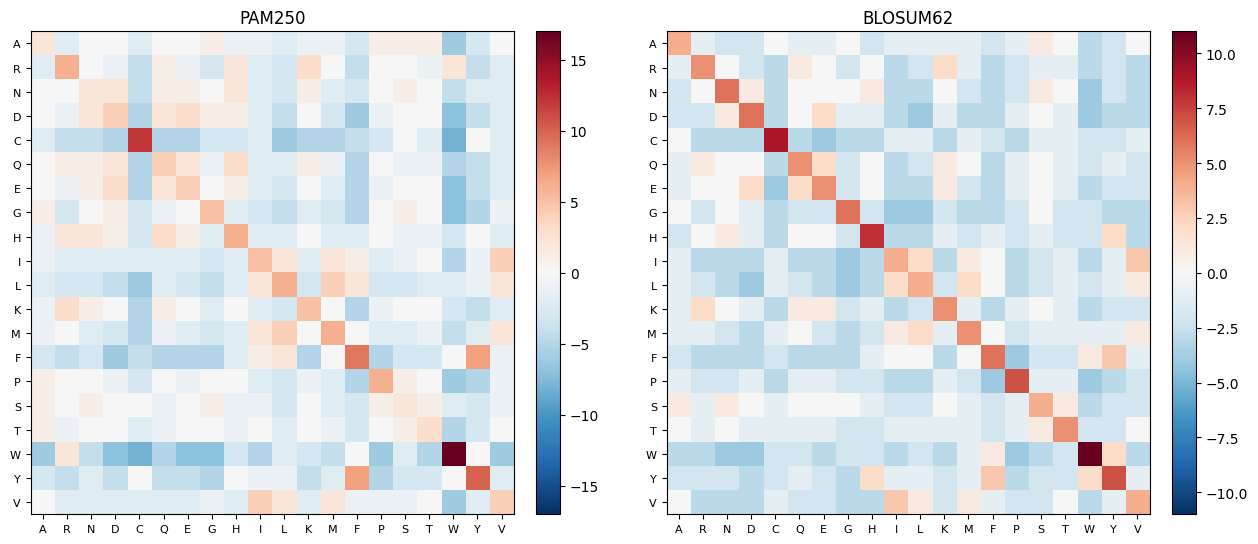

In [6]:
# Alfabeto padrão de aminoácidos (sem os símbolos de ambiguidade B/Z/X/*)
aa_alphabet = list("ARNDCQEGHILKMFPSTWYV")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_matrix_heatmap(matrix_pam250, "PAM250", alphabet=aa_alphabet, ax=axes[0])
plot_matrix_heatmap(matrix_blosum62, "BLOSUM62", alphabet=aa_alphabet, ax=axes[1])
plt.tight_layout()
plt.show()

Repare que a escala de cores das duas matrizes é diferente (a PAM250 tem um score máximo de 17 no W, contra 11 na BLOSUM62), então compare *padrões relativos* (quais pares são vermelhos/azuis fortes em cada uma) e não só os números absolutos.

Também dá pra visualizar diretamente a *diferença* entre as duas matrizes — onde elas mais discordam sobre o quão "aceitável" é uma substituição:

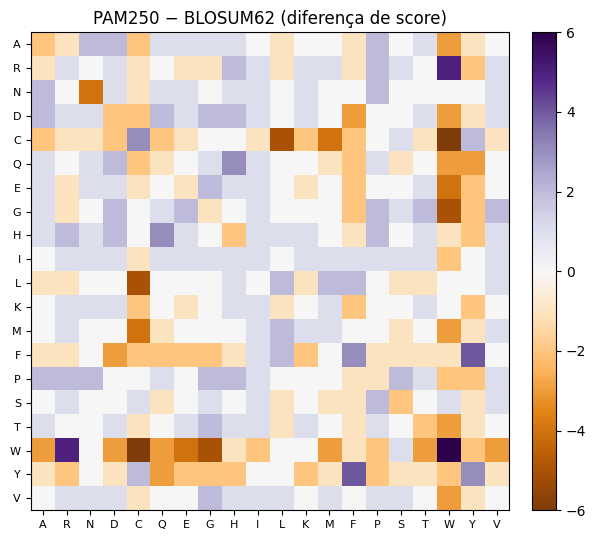

In [7]:
arr_pam, _ = matrix_to_array(matrix_pam250, aa_alphabet)
arr_blosum, _ = matrix_to_array(matrix_blosum62, aa_alphabet)

diff = arr_pam - arr_blosum

fig, ax = plt.subplots(figsize=(6.5, 5.5))
vmax = np.abs(diff).max()
im = ax.imshow(diff, cmap="PuOr", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(aa_alphabet)))
ax.set_yticks(range(len(aa_alphabet)))
ax.set_xticklabels(aa_alphabet, fontsize=8)
ax.set_yticklabels(aa_alphabet, fontsize=8)
ax.set_title("PAM250 − BLOSUM62 (diferença de score)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

E se eu quiser um alinhamento de ácidos nucleicos ao invés de proteínas?

In [8]:
matrix_nuc44 = substitution_matrices.load("NUC.4.4")
print(matrix_nuc44)

#  
#  This matrix was created by Todd Lowe   12/10/92
#  
#  Uses ambiguous nucleotide codes, probabilities rounded to
#  nearest integer
#  
#  Lowest score = -4, Highest score = 5
#  
     A    T    G    C    S    W    R    Y    K    M    B    V    H    D    N
A  5.0 -4.0 -4.0 -4.0 -4.0  1.0  1.0 -4.0 -4.0  1.0 -4.0 -1.0 -1.0 -1.0 -2.0
T -4.0  5.0 -4.0 -4.0 -4.0  1.0 -4.0  1.0  1.0 -4.0 -1.0 -4.0 -1.0 -1.0 -2.0
G -4.0 -4.0  5.0 -4.0  1.0 -4.0  1.0 -4.0  1.0 -4.0 -1.0 -1.0 -4.0 -1.0 -2.0
C -4.0 -4.0 -4.0  5.0  1.0 -4.0 -4.0  1.0 -4.0  1.0 -1.0 -1.0 -1.0 -4.0 -2.0
S -4.0 -4.0  1.0  1.0 -1.0 -4.0 -2.0 -2.0 -2.0 -2.0 -1.0 -1.0 -3.0 -3.0 -1.0
W  1.0  1.0 -4.0 -4.0 -4.0 -1.0 -2.0 -2.0 -2.0 -2.0 -3.0 -3.0 -1.0 -1.0 -1.0
R  1.0 -4.0  1.0 -4.0 -2.0 -2.0 -1.0 -4.0 -2.0 -2.0 -3.0 -1.0 -3.0 -1.0 -1.0
Y -4.0  1.0 -4.0  1.0 -2.0 -2.0 -4.0 -1.0 -2.0 -2.0 -1.0 -3.0 -1.0 -3.0 -1.0
K -4.0  1.0  1.0 -4.0 -2.0 -2.0 -2.0 -2.0 -1.0 -4.0 -1.0 -3.0 -3.0 -1.0 -1.0
M  1.0 -4.0 -4.0  1.0 -2.0 -2.0 -2.0 -2.0 -

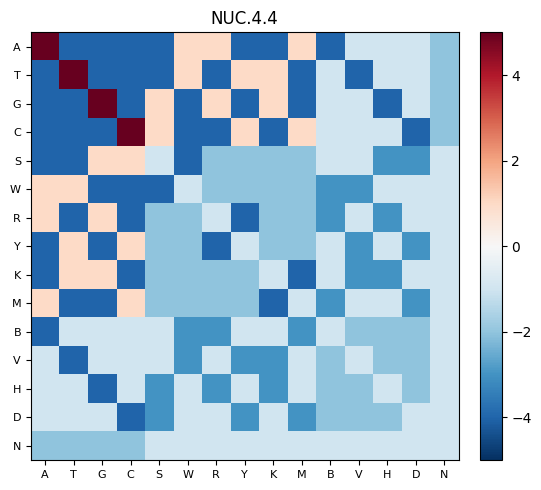

In [9]:
nuc_alphabet = list("ATGCSWRYKMBVHDN")
plot_matrix_heatmap(matrix_nuc44, "NUC.4.4", alphabet=nuc_alphabet, cmap="RdBu_r")
plt.tight_layout()
plt.show()

Também existem matrizes de substiuição para códons, ao invés de bases.

**Q2-** Discuta a diferença entre essas duas matrizes. O que são as letras nos eixos da matriz NUC.4.4? Qual a importância deste tipo de redundância no código de letras?

Para ajudar a pensar sobre isso, algumas perguntas mais específicas:
- Por que o par R×Y recebe o pior score possível (-4), igual a um mismatch entre duas bases puras (ex. A×C)?
- Por que N recebe scores uniformemente baixos (-1 ou -2) em vez de 0 (neutro)?
- Como isso se relaciona com bases de baixa qualidade (Phred baixo) observadas no sequenciamento — em que situações um basecaller atribuiria um código como R, Y ou N em vez de uma base pura?

### Colocando a matriz NUC.4.4 em prática: alinhamento com `PairwiseAligner`

Olhar a matriz "crua" é abstrato. Vamos usá-la de fato para alinhar duas sequências curtas — uma delas contendo códigos de ambiguidade — e ver como os scores da matriz afetam o resultado.

In [10]:
aligner = PairwiseAligner()
aligner.substitution_matrix = matrix_nuc44
aligner.mode = "global"
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

# seq2 tem alguns códigos de ambiguidade nas posições 4, 6 e 8
seq1 = "ATGCATGCATGC"
seq2 = "ATGYATRCATNC"

alignments = aligner.align(seq1, seq2)
best = alignments[0]
print(best)
print(f"Score do alinhamento: {best.score}")

target            0 ATGCATGCATGC 12
                  0 |||.||.|||.| 12
query             0 ATGYATRCATNC 12

Score do alinhamento: 45.0


Repare nos pares alinhados posição a posição:
- **C×Y** (posição 4): Y = C ou T, então esse par recebe score **+1** (parcialmente compatível), bem melhor que um mismatch puro como C×A (**-4**).
- **G×R** (posição 6): R = A ou G, também **+1**.
- **G×N** (posição 8): N pode ser qualquer base, então o score é **-2** — baixo, mas não tão penalizado quanto um mismatch certo.

Isso mostra na prática por que a matriz NUC.4.4 é útil: ela deixa o alinhador "tolerar" ambiguidade sem tratar tudo como puro acerto ou erro. Tente editar `seq2` acima trocando os códigos de ambiguidade e veja como o score muda.

In [11]:
matrix_schneider = substitution_matrices.load("SCHNEIDER")
print(matrix_schneider)

#  Adrian Schneider, Gina M. Cannarozzi, and Gaston H. Gonnet:
#  "Empirical codon substitution matrix."
#  BMC Bioinformatics 6:134 (2005).
#  Additional File 3.
#  PMID 15927081
      AAA   AAC   AAG   AAT   ACA   ACC   ACG   ACT   AGA   AGC   AGG   AGT   ATA   ATC   ATG   ATT   CAA   CAC   CAG   CAT   CCA   CCC   CCG   CCT   CGA   CGC   CGG   CGT   CTA   CTC   CTG   CTT   GAA   GAC   GAG   GAT   GCA   GCC   GCG   GCT   GGA   GGC   GGG   GGT   GTA   GTC   GTG   GTT   TAA   TAC   TAG   TAT   TCA   TCC   TCG   TCT   TGA   TGC   TGG   TGT   TTA   TTC   TTG   TTT
AAA  11.6  -2.7   9.7  -1.7  -2.7  -6.4  -3.9  -5.6   5.1  -5.0   3.6  -4.2  -6.3 -13.0  -7.1 -11.5   0.4  -6.0  -1.9  -5.3  -8.5 -11.2  -8.9 -10.8   2.1   0.0   1.4   0.2 -10.2 -13.5 -13.0 -12.5  -2.6  -8.5  -5.0  -8.1  -6.3  -9.9  -7.5  -9.0  -7.1 -10.2  -8.2  -9.2  -8.2 -12.5 -11.1 -11.4 -50.0 -14.8 -50.0 -13.8  -7.3 -10.1  -8.4  -9.1 -50.0 -13.0 -13.5 -12.4 -10.7 -18.1 -11.8 -17.2
AAC  -2.7  13.0  -3.3  10.9  -3.5  -0.4  -3.

A matriz **SCHNEIDER** é uma matriz de substituição de **códons** (trincas de nucleotídeos), e não de bases isoladas ou aminoácidos — por isso ela é 64×64 em vez de 4×4 ou 20×20. Cada eixo lista um códon possível (ex. `AAA`, `AAC`, ..., `TTT`).

Alguns pontos para observar:
- Ela captura a **degenerescência do código genético**. Sabendo disso, explique qual é a diferença de valores de pontuação entre códons sinônimos (que codificam o mesmo aminoácido, ex. `CTT`, `CTC`, `CTA`, `CTG` = Leucina) e códons não-sinônimos. Qual o conceito biológico que estaria por trás disso?
- Verifique os **códons de parada** (`TAA`, `TAG`, `TGA`). Qual o valor da pontuação para alinhamento contra qualquer códon que não seja outro stop? O que isso significa evolutivamente ou biologicamente?
- Em quais situações essa matriz é útil, comparando com a NUC.4.4?

## Síntese

Resuma com suas próprias palavras:
1. Por que existem matrizes diferentes (PAM250 vs BLOSUM62) para o mesmo tipo de dado (proteínas)?
2. O que os códigos de ambiguidade da NUC.4.4 representam biologicamente, e por que a matriz não trata todo mismatch da mesma forma?
3. Em que situação você usaria uma matriz de códons (SCHNEIDER) em vez de uma matriz de nucleotídeos (NUC.4.4)?